# 23 — GCD model on GLOBE: best-patch-per-image selection
Instead of keeping all cloud-confident patches per image (notebook 21), select only the
**single highest-confidence patch** per GLOBE photo. One tight, cloud-centric crop per image
should look more like a curated GCD image and reduce domain shift without any fine-tuning.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as tvm
import torchvision.transforms.v2 as T
import torchvision.transforms as T_filt
from torchvision.transforms.v2 import InterpolationMode
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
from PIL import Image
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
GLOBE_ROOT      = Path('../resources/cloud-images/NASA_GLOBE_CD/extract_filtered-thr99-sam3000')
FILTER_CKPT     = Path('../models/multihead_resnet18_cloud_sky.pth')
GCD_CKPT        = Path('../models/best_cloudensenet_15_2.pt')
BATCH_SIZE      = 64
FILTER_BATCH    = 256
CROP_FRACTION   = 0.5
OVERLAP         = 0.25
OUTPUT_SIZE     = 224
device          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

GLOBE_TO_GCD = {
    'Ac': '2_altocumulus',
    'Cb': '6_cumulonimbus',
    'Ci': '3_cirrus',
    'Cu': '1_cumulus',
    'Sc': '5_stratocumulus',
}
class_names  = sorted(GLOBE_TO_GCD.values())
label_to_idx = {c: i for i, c in enumerate(class_names)}
print('Classes:', class_names)

device: cpu
Classes: ['1_cumulus', '2_altocumulus', '3_cirrus', '5_stratocumulus', '6_cumulonimbus']


In [3]:
eval_tf = T.Compose([
    T.Resize((OUTPUT_SIZE, OUTPUT_SIZE), interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

filter_tf = T_filt.Compose([
    T_filt.ToTensor(),
    T_filt.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [4]:
class PatchDataset(Dataset):
    """Slides proportional crops over each image; pixel data loaded lazily."""

    def __init__(self, paths, encoded_labels,
                 crop_fraction=0.5, overlap=0.25, output_size=224,
                 transform=None):
        self.output_size = output_size
        self.transform   = transform
        self.samples     = []
        for path, label in zip(paths, encoded_labels):
            try:
                W, H = Image.open(path).size
            except Exception:
                continue
            crop_size = max(output_size, int(min(W, H) * crop_fraction))
            stride    = max(1, int(crop_size * (1 - overlap)))
            for y in range(0, H - crop_size + 1, stride):
                for x in range(0, W - crop_size + 1, stride):
                    self.samples.append((path, label, (x, y, x + crop_size, y + crop_size)))

    @classmethod
    def from_samples(cls, samples, output_size=224, transform=None):
        obj             = cls.__new__(cls)
        obj.samples     = samples
        obj.output_size = output_size
        obj.transform   = transform
        return obj

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, box = self.samples[idx]
        img  = Image.open(path).convert('RGB')
        crop = img.crop(box).resize((self.output_size, self.output_size), Image.BILINEAR)
        if self.transform:
            crop = self.transform(crop)
        return crop, label

In [5]:
class MultiHeadResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base          = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.head1    = base.fc
        self.head2    = nn.Linear(512, num_classes)
        for p in self.backbone.parameters(): p.requires_grad = False
        for p in self.head1.parameters():    p.requires_grad = False

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        return self.head1(feat), self.head2(feat)


ckpt         = torch.load(FILTER_CKPT, map_location='cpu', weights_only=False)
filter_cls   = ckpt['classes']
cloud_idx    = filter_cls.index('cloud')
filter_model = MultiHeadResNet18(num_classes=len(filter_cls))
filter_model.load_state_dict(ckpt['model_state_dict'])
filter_model.eval().to(device)
print(f'Filter model loaded  |  classes: {filter_cls}  |  cloud_idx={cloud_idx}')

Filter model loaded  |  classes: ['clear_sky', 'cloud']  |  cloud_idx=1


In [6]:
def best_patch_per_image(samples, batch_size=FILTER_BATCH):
    """For each source image, keep the patch with the highest cloud confidence score."""
    path_to_indices = defaultdict(list)
    for i, (path, label, box) in enumerate(samples):
        path_to_indices[path].append(i)

    best_samples = []
    for path, indices in tqdm(path_to_indices.items(), desc='Best patch per image'):
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            continue
        tensors, valid = [], []
        for i in indices:
            _, _, box = samples[i]
            try:
                crop = img.crop(box).resize((OUTPUT_SIZE, OUTPUT_SIZE), Image.BILINEAR)
                tensors.append(filter_tf(crop))
                valid.append(i)
            except Exception:
                pass
        if not tensors:
            continue
        best_score, best_sample = -1, None
        for b in range(0, len(tensors), batch_size):
            batch = torch.stack(tensors[b:b + batch_size]).to(device)
            with torch.no_grad():
                _, out = filter_model(batch)
                probs = F.softmax(out.float(), dim=1)[:, cloud_idx].cpu().tolist()
            for j, score in enumerate(probs):
                if score > best_score:
                    best_score = score
                    best_sample = samples[valid[b + j]]
        if best_sample is not None:
            best_samples.append(best_sample)

    return best_samples

In [7]:
all_paths, all_labels = [], []
for globe_cls, gcd_cls in GLOBE_TO_GCD.items():
    cls_dir = GLOBE_ROOT / globe_cls
    label   = label_to_idx[gcd_cls]
    imgs    = sorted(p for p in cls_dir.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})
    all_paths.extend(imgs)
    all_labels.extend([label] * len(imgs))
    print(f'{globe_cls} → {gcd_cls}: {len(imgs):,} images')

print(f'\nTotal images: {len(all_paths):,}')
raw_ds = PatchDataset(all_paths, all_labels, CROP_FRACTION, OVERLAP, OUTPUT_SIZE)
print(f'Total patches (before selection): {len(raw_ds):,}')

Ac → 2_altocumulus: 3,000 images
Cb → 6_cumulonimbus: 3,000 images
Ci → 3_cirrus: 3,000 images
Cu → 1_cumulus: 3,000 images
Sc → 5_stratocumulus: 3,000 images

Total images: 15,000
Total patches (before selection): 98,908


In [8]:
best_samples = best_patch_per_image(raw_ds.samples)
print(f'Selected patches: {len(best_samples):,}  (expected ~{len(all_paths):,}, one per image)')

Best patch per image: 100%|██████████| 14941/14941 [25:23<00:00,  9.80it/s]   

Selected patches: 14,941  (expected ~15,000, one per image)


In [9]:
class TopBlock(nn.Module):
    def __init__(self, in_features, n_classes, hidden_dim=512, dropout=0.5):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(p=dropout / 2),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.block(x)


model            = tvm.densenet121(weights=None).to(device)
model.classifier = TopBlock(in_features=1024, n_classes=5).to(device)
model.load_state_dict(torch.load(GCD_CKPT, map_location=device, weights_only=True))
model.eval()
print(f'GCD model loaded from {GCD_CKPT}')

GCD model loaded from ../models/best_cloudensenet_15_2.pt


In [10]:
infer_ds     = PatchDataset.from_samples(best_samples, OUTPUT_SIZE, eval_tf)
infer_loader = DataLoader(infer_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_preds, all_targets = [], []
with torch.no_grad():
    for X, y in tqdm(infer_loader, desc='Inference'):
        preds = torch.argmax(model(X.to(device)), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.numpy())

correct = sum(p == t for p, t in zip(all_preds, all_targets))
print(f'Overall accuracy: {correct}/{len(all_targets)} = {correct/len(all_targets):.4f}')

Inference: 100%|██████████| 234/234 [19:19<00:00,  4.95s/it]

Overall accuracy: 5159/14941 = 0.3453


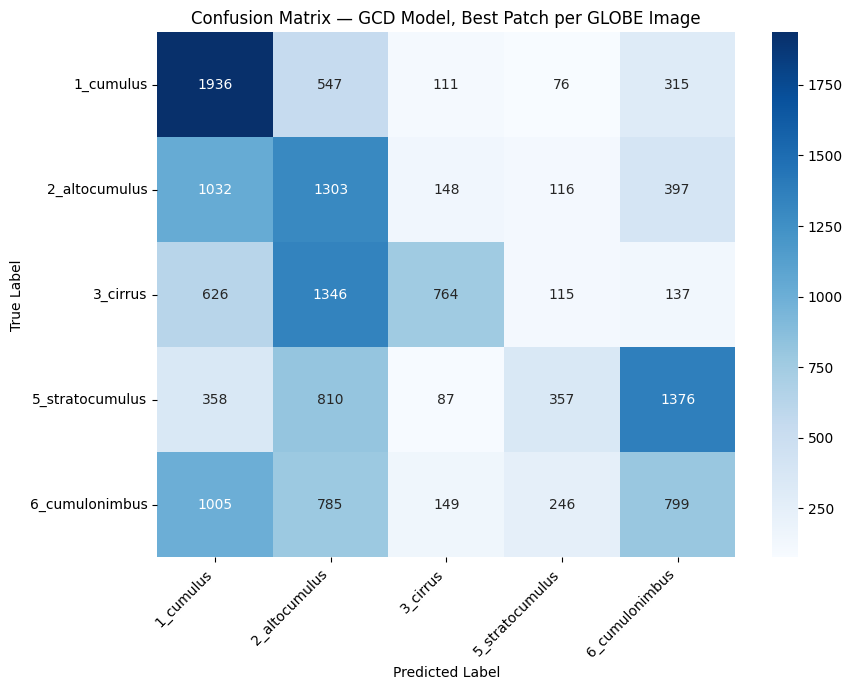

In [11]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — GCD Model, Best Patch per GLOBE Image')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../confusion matrix GCD best patch per image.png', dpi=150)
plt.show()

In [12]:
print(classification_report(all_targets, all_preds, target_names=class_names, digits=3))

                 precision    recall  f1-score   support

      1_cumulus      0.391     0.649     0.488      2985
  2_altocumulus      0.272     0.435     0.335      2996
       3_cirrus      0.607     0.256     0.360      2988
5_stratocumulus      0.392     0.119     0.183      2988
 6_cumulonimbus      0.264     0.268     0.266      2984

       accuracy                          0.345     14941
      macro avg      0.385     0.345     0.326     14941
   weighted avg      0.385     0.345     0.326     14941

